In [15]:
## Plot the results from the BNNs on one graph
from __future__ import annotations

import argparse
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score

try:
    from sklearn.metrics import confusion_matrix
except ImportError as exc:  # pragma: no cover
    raise SystemExit("This script needs scikit-learn: pip install scikit-learn") from exc

In [16]:
df = pd.read_csv('echonext_metadata_100k.csv')
le = LabelEncoder()
SHD = le.fit_transform(df['shd_moderate_or_greater_flag'].values.reshape(-1,1))
id    = le.fit_transform(df['split'].values.reshape(-1,1))
id_test  = np.where(id!=2)
n_test=20000
ytest = SHD[id_test][:n_test]


c:\Users\colebanm\uq_disc\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\colebanm\uq_disc\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [17]:
def load_npz(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=True) as data:
        return {key: data[key] for key in data.files}
f_plot_name = '20 neurons, Dropout$=0.50$, 8K Training'
f_save_name = '20neuron_drop20_70Ktrain'
results_3_ECG = load_npz('outputs/NN_roc_results_3_ECG_20neuron_70000train_20000test_dropout20_TANH.npz')
results_3_ECG2 = load_npz('outputs/NN_roc_results_3_ECG_ECHO_20neuron_70000train_20000test_dropout20_TANH.npz')
results_3_Echo = load_npz('outputs/NN_roc_results_3_ALLDATA_20neuron_70000train_20000test_dropout20_TANH.npz')
results_5_ECG = load_npz('outputs/NN_roc_results_5_ECG_20neuron_70000train_20000test_dropout20_TANH.npz')
results_5_ECG2 = load_npz('outputs/NN_roc_results_5_ECG_ECHO_20neuron_70000train_20000test_dropout20_TANH.npz')
results_5_Echo = load_npz('outputs/NN_roc_results_5_ALLDATA_20neuron_70000train_20000test_dropout20_TANH.npz')
results_10_ECG = load_npz('outputs/NN_roc_results_10_ECG_20neuron_70000train_20000test_dropout20_TANH.npz')
results_10_ECG2 = load_npz('outputs/NN_roc_results_10_ECG_ECHO_20neuron_70000train_20000test_dropout20_TANH.npz')
results_10_Echo = load_npz('outputs/NN_roc_results_10_ALLDATA_20neuron_70000train_20000test_dropout20_TANH.npz')



FileNotFoundError: [Errno 2] No such file or directory: 'outputs/NN_roc_results_3_ECG_20neuron_70000train_20000test_dropout20_TANH.npz'

In [ ]:
def plot_roc_with_uncertainty(results,ax,Dataname):
    fpr_grid = results.get("fpr_grid")
    tpr_mean = results.get("tpr_mean")
    tpr_lower = results.get("tpr_lower")
    tpr_upper = results.get("tpr_upper")
    tpr_samples = results.get("tpr_samples")
    auc_samples = results.get("auc_samples")
    auc_mean = float(np.asarray(results.get("auc_mean", np.nan)))
    auc_ci = np.asarray(results.get("auc_ci", [np.nan, np.nan])).ravel()

    if fpr_grid is None or tpr_mean is None:
        print(f"[skip]: missing fpr_grid or tpr_mean, cannot plot ROC uncertainty.")
        return


    if tpr_samples is not None and tpr_samples.ndim == 2:
        rng = np.random.default_rng(123)
        n_draw = min(500, tpr_samples.shape[0])
        draw_idx = rng.choice(tpr_samples.shape[0], size=n_draw, replace=False)
        # for idx in draw_idx:
            # ax.plot(fpr_grid, tpr_samples[idx], color="0.65", alpha=0.252, linewidth=0.7)

    if tpr_lower is not None and tpr_upper is not None:
        ax.fill_between(fpr_grid, tpr_lower, tpr_upper, alpha=0.25)

    label = f"{Dataname} Posterior mean ROC, AUC={auc_mean:.3f}"
    if auc_ci.size >= 2 and np.all(np.isfinite(auc_ci[:2])):
        label += f" [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]"
    ax.plot(fpr_grid, tpr_mean, linewidth=2.5,label=label)

    # if "roc_fpr" in results and "roc_tpr" in results:
        # ax.plot(results["roc_fpr"], results["roc_tpr"], linestyle="--", linewidth=1.5)

    
    # fig.savefig(out_path, dpi=dpi)

    # if auc_samples is not None:
    #     fig2, ax2 = plt.subplots(figsize=(7.5, 4.5))
    #     ax2.hist(auc_samples, bins=30, alpha=0.8)
    #     ax2.axvline(np.mean(auc_samples), linestyle="--", linewidth=2, label=f"Mean={np.mean(auc_samples):.3f}")
    #     if auc_ci.size >= 2:
    #         ax2.axvline(auc_ci[0], linestyle=":", linewidth=2, label=f"Lower={auc_ci[0]:.3f}")
    #         ax2.axvline(auc_ci[1], linestyle=":", linewidth=2, label=f"Upper={auc_ci[1]:.3f}")
    #     ax2.set_xlabel("AUC")
    #     ax2.set_ylabel("Posterior sample count")
    #     ax2.set_title(f"AUC posterior distribution\n{title}")
    #     ax2.legend()
    #     fig2.tight_layout()
    #     fig2.savefig(out_path.with_name(out_path.stem + "_auc_hist.png"), dpi=dpi)

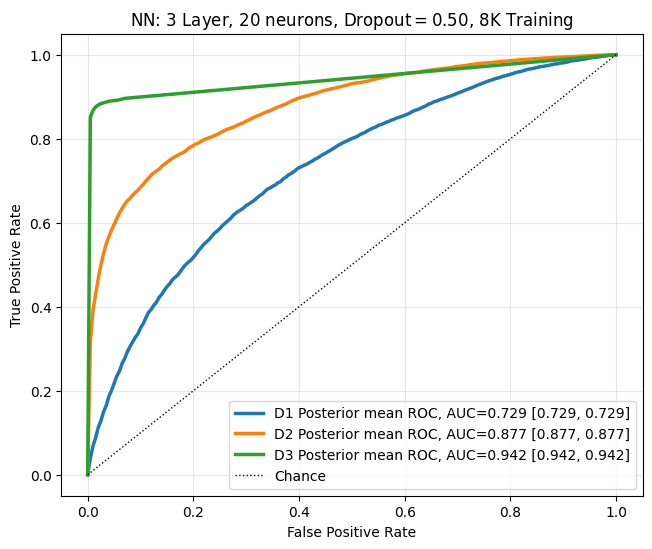

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
plot_roc_with_uncertainty(results_3_ECG,ax,'D1')
plot_roc_with_uncertainty(results_3_ECG2,ax, 'D2')
plot_roc_with_uncertainty(results_3_Echo,ax,'D3')
ax.plot([0, 1], [0, 1], linestyle=":", linewidth=1.0, color="k", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"NN: 3 Layer, {f_plot_name}")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
# fig.savefig(f"PaperFigures/NN_ROC_3layer_{f_save_name}")




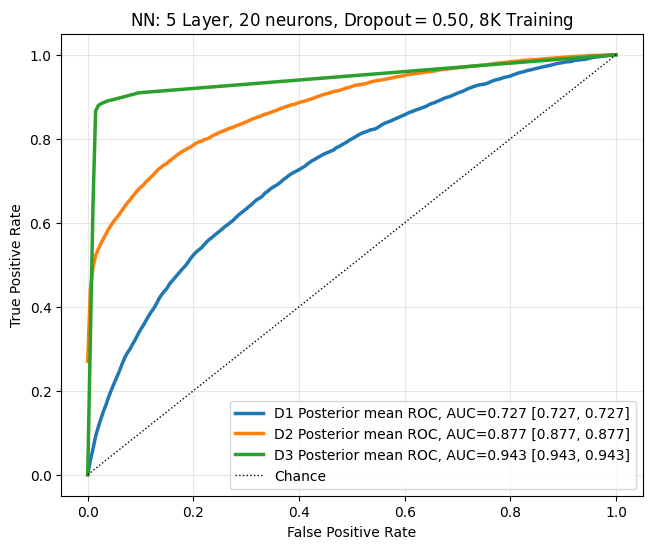

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
plot_roc_with_uncertainty(results_5_ECG,ax,'D1')
plot_roc_with_uncertainty(results_5_ECG2,ax, 'D2')
plot_roc_with_uncertainty(results_5_Echo,ax,'D3')
ax.plot([0, 1], [0, 1], linestyle=":", linewidth=1.0, color="k", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"NN: 5 Layer, {f_plot_name}")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
# fig.savefig(f"PaperFigures/NN_ROC_5layer_{f_save_name}")




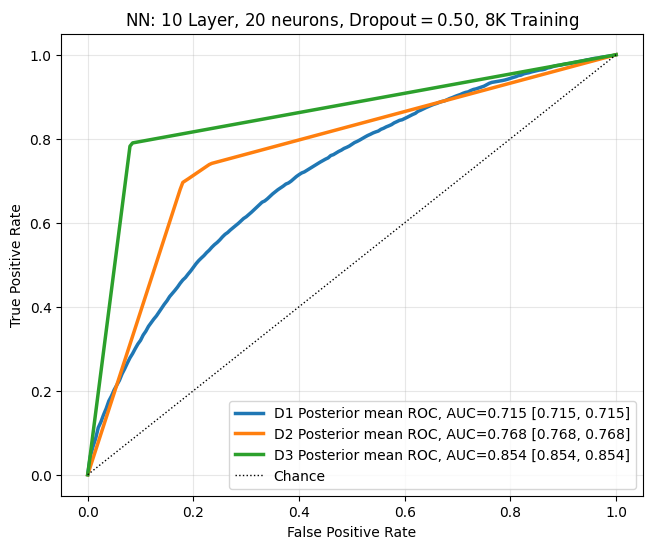

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
plot_roc_with_uncertainty(results_10_ECG,ax,'D1')
plot_roc_with_uncertainty(results_10_ECG2,ax, 'D2')
plot_roc_with_uncertainty(results_10_Echo,ax,'D3')
ax.plot([0, 1], [0, 1], linestyle=":", linewidth=1.0, color="k", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"NN: 10 Layer, {f_plot_name}")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
# fig.savefig(f"PaperFigures/NN_ROC_10layer_{f_save_name}")




In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score, brier_score_loss

# ============================================================
# Validation
# ============================================================

def validate_binary_inputs(y_true: np.ndarray, y_prob: np.ndarray) -> None:
    if y_true.ndim != 1:
        raise ValueError("y_true must be 1D.")
    if y_prob.ndim != 1:
        raise ValueError("y_prob must be 1D.")
    if len(y_true) != len(y_prob):
        raise ValueError("y_true and y_prob must have same length.")
    if not np.all(np.isin(y_true, [0, 1])):
        raise ValueError("y_true must contain only 0 and 1.")
    if np.any((y_prob < 0) | (y_prob > 1)):
        raise ValueError("y_prob must lie in [0, 1].")


def validate_bayesian_inputs(y_true: np.ndarray, y_prob_samples: np.ndarray) -> None:
    if y_true.ndim != 1:
        raise ValueError("y_true must be 1D.")
    if y_prob_samples.ndim != 2:
        raise ValueError("y_prob_samples must be 2D with shape (n_samples, n_draws).")
    if len(y_true) != y_prob_samples.shape[0]:
        raise ValueError("y_true and y_prob_samples must agree in n_samples.")
    if not np.all(np.isin(y_true, [0, 1])):
        raise ValueError("y_true must contain only 0 and 1.")
    if np.any((y_prob_samples < 0) | (y_prob_samples > 1)):
        raise ValueError("All posterior predictive probabilities must lie in [0, 1].")


# ============================================================
# Frequentist-style metrics using sklearn
# ============================================================

def compute_auprc_sklearn(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    validate_binary_inputs(y_true, y_prob)
    return float(average_precision_score(y_true, y_prob))


def compute_brier_sklearn(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    validate_binary_inputs(y_true, y_prob)
    return float(brier_score_loss(y_true, y_prob))


def compute_calibration_curve_sklearn(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 10,
    strategy: str = "uniform",
) -> Dict[str, np.ndarray]:
    """
    Returns calibration curve points using sklearn.calibration.calibration_curve.

    Outputs:
        prob_true: observed fraction of positives in each non-empty bin
        prob_pred: mean predicted probability in each non-empty bin
    """
    validate_binary_inputs(y_true, y_prob)

    prob_true, prob_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy=strategy,
    )

    return {
        "prob_true": prob_true,
        "prob_pred": prob_pred,
    }


# ============================================================
# ECE (not built into sklearn)
# ============================================================

def compute_ece(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 10,
    strategy: str = "uniform",
) -> Tuple[float, Dict[str, np.ndarray]]:
    """
    Expected Calibration Error for binary classification.

    This is not built into sklearn, so we compute it directly.
    """
    validate_binary_inputs(y_true, y_prob)

    if strategy not in {"uniform", "quantile"}:
        raise ValueError("strategy must be 'uniform' or 'quantile'.")

    n = len(y_true)

    if strategy == "uniform":
        bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    else:
        bin_edges = np.quantile(y_prob, np.linspace(0.0, 1.0, n_bins + 1))
        bin_edges[0] = 0.0
        bin_edges[-1] = 1.0
        bin_edges = np.maximum.accumulate(bin_edges)

    bin_counts = np.zeros(n_bins, dtype=int)
    bin_acc = np.full(n_bins, np.nan)
    bin_conf = np.full(n_bins, np.nan)

    ece = 0.0

    for b in range(n_bins):
        left = bin_edges[b]
        right = bin_edges[b + 1]

        if b == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        count = int(np.sum(mask))
        bin_counts[b] = count

        if count > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            bin_acc[b] = acc
            bin_conf[b] = conf
            ece += (count / n) * abs(acc - conf)

    details = {
        "bin_edges": bin_edges,
        "bin_counts": bin_counts,
        "bin_accuracy": bin_acc,
        "bin_confidence": bin_conf,
    }

    return float(ece), details


# ============================================================
# Bayesian summaries
# ============================================================

def predictive_mean(y_prob_samples: np.ndarray) -> np.ndarray:
    return np.mean(y_prob_samples, axis=1)


def predictive_variance(y_prob_samples: np.ndarray) -> np.ndarray:
    return np.var(y_prob_samples, axis=1, ddof=1)


def predictive_entropy(y_prob: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    p = np.clip(y_prob, eps, 1.0 - eps)
    return -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))


# ============================================================
# Coverage-risk curve (custom; not in sklearn)
# ============================================================

def hard_predictions(y_prob: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    return (y_prob >= threshold).astype(int)


def compute_coverage_risk_curve(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    uncertainty: np.ndarray,
    threshold: float = 0.5,
    n_points: int = 50,
) -> Dict[str, np.ndarray]:
    """
    Sort by increasing uncertainty, then compute risk on retained least-uncertain cases.
    """
    validate_binary_inputs(y_true, y_prob)

    if uncertainty.ndim != 1 or len(uncertainty) != len(y_true):
        raise ValueError("uncertainty must be 1D with same length as y_true.")

    n = len(y_true)
    order = np.argsort(uncertainty)  # least uncertain first

    y_true_sorted = y_true[order]
    y_pred_sorted = hard_predictions(y_prob[order], threshold=threshold)
    unc_sorted = uncertainty[order]

    coverages = np.linspace(1.0 / n, 1.0, min(n_points, n))
    risks = np.zeros_like(coverages)
    retained = np.zeros_like(coverages, dtype=int)
    uncertainty_threshold = np.zeros_like(coverages)

    cumulative_errors = np.cumsum((y_pred_sorted != y_true_sorted).astype(float))

    for i, c in enumerate(coverages):
        k = max(1, int(np.floor(c * n)))
        retained[i] = k
        risks[i] = cumulative_errors[k - 1] / k
        uncertainty_threshold[i] = unc_sorted[k - 1]

    return {
        "coverage": coverages,
        "risk": risks,
        "retained_count": retained,
        "uncertainty_threshold": uncertainty_threshold,
    }


# ============================================================
# Dataclasses
# ============================================================

@dataclass
class FrequentistMetrics:
    auprc: float
    brier_score: float
    ece: float
    calibration: Dict[str, np.ndarray]
    ece_details: Dict[str, np.ndarray]
    coverage_risk: Dict[str, np.ndarray]


@dataclass
class BayesianMetrics:
    auprc: float
    brier_score: float
    ece: float
    calibration: Dict[str, np.ndarray]
    ece_details: Dict[str, np.ndarray]
    coverage_risk_variance: Dict[str, np.ndarray]
    coverage_risk_entropy: Dict[str, np.ndarray]
    mean_prob: np.ndarray
    variance: np.ndarray
    entropy: np.ndarray


# ============================================================
# Evaluation wrappers
# ============================================================

def evaluate_frequentist_model(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 10,
    calibration_strategy: str = "uniform",
    threshold: float = 0.5,
    n_coverage_points: int = 50,
) -> FrequentistMetrics:
    """
    Frequentist NN:
      - use y_prob directly
      - uncertainty proxy = min(p, 1-p)
    """
    validate_binary_inputs(y_true, y_prob)

    auprc = compute_auprc_sklearn(y_true, y_prob)
    brier = compute_brier_sklearn(y_true, y_prob)
    calibration = compute_calibration_curve_sklearn(
        y_true, y_prob, n_bins=n_bins, strategy=calibration_strategy
    )
    ece, ece_details = compute_ece(
        y_true, y_prob, n_bins=n_bins, strategy=calibration_strategy
    )

    # Confidence-based uncertainty proxy
    uncertainty = np.minimum(y_prob, 1.0 - y_prob)

    coverage_risk = compute_coverage_risk_curve(
        y_true=y_true,
        y_prob=y_prob,
        uncertainty=uncertainty,
        threshold=threshold,
        n_points=n_coverage_points,
    )

    return FrequentistMetrics(
        auprc=auprc,
        brier_score=brier,
        ece=ece,
        calibration=calibration,
        ece_details=ece_details,
        coverage_risk=coverage_risk,
    )


def evaluate_bayesian_model(
    y_true: np.ndarray,
    y_prob_samples: np.ndarray,
    n_bins: int = 10,
    calibration_strategy: str = "uniform",
    threshold: float = 0.5,
    n_coverage_points: int = 50,
) -> BayesianMetrics:
    """
    Bayesian NN:
      - compute posterior predictive mean probability
      - compute variance and entropy as uncertainty summaries
    """
    validate_bayesian_inputs(y_true, y_prob_samples)

    mean_prob = predictive_mean(y_prob_samples)
    variance = predictive_variance(y_prob_samples)
    entropy = predictive_entropy(mean_prob)

    auprc = compute_auprc_sklearn(y_true, mean_prob)
    brier = compute_brier_sklearn(y_true, mean_prob)
    calibration = compute_calibration_curve_sklearn(
        y_true, mean_prob, n_bins=n_bins, strategy=calibration_strategy
    )
    ece, ece_details = compute_ece(
        y_true, mean_prob, n_bins=n_bins, strategy=calibration_strategy
    )

    coverage_risk_variance = compute_coverage_risk_curve(
        y_true=y_true,
        y_prob=mean_prob,
        uncertainty=variance,
        threshold=threshold,
        n_points=n_coverage_points,
    )

    coverage_risk_entropy = compute_coverage_risk_curve(
        y_true=y_true,
        y_prob=mean_prob,
        uncertainty=entropy,
        threshold=threshold,
        n_points=n_coverage_points,
    )

    return BayesianMetrics(
        auprc=auprc,
        brier_score=brier,
        ece=ece,
        calibration=calibration,
        ece_details=ece_details,
        coverage_risk_variance=coverage_risk_variance,
        coverage_risk_entropy=coverage_risk_entropy,
        mean_prob=mean_prob,
        variance=variance,
        entropy=entropy,
    )

In [ ]:
def plot_pr_curves(
    y_true,
    y_prob_freq=None,
    y_prob_bayes_samples=None,
    bayes_label="Bayesian NN",
    freq_label="Frequentist NN",
    title="Precision-Recall Curve",
    plt=None,
    plot_prev=False,
):
    """
    Plot precision-recall curves for frequentist and/or Bayesian models.

    Parameters
    ----------
    y_true : array-like, shape (n_samples,)
        Binary ground-truth labels.
    y_prob_freq : array-like, shape (n_samples,), optional
        Predicted probabilities from a frequentist model.
    y_prob_bayes_samples : array-like, shape (n_samples, n_draws), optional
        Posterior predictive probabilities from a Bayesian model.
    bayes_label : str
        Label for Bayesian model in legend.
    freq_label : str
        Label for frequentist model in legend.
    title : str
        Plot title.
    figsize : tuple
        Figure size.
    """
    y_true = np.asarray(y_true)

    if y_true.ndim != 1:
        raise ValueError("y_true must be 1D.")
    if not np.all(np.isin(y_true, [0, 1])):
        raise ValueError("y_true must contain only 0 and 1.")


    # Baseline prevalence line
    prevalence = np.mean(y_true)
    
    # Frequentist model
    if y_prob_freq is not None:
        y_prob_freq = np.asarray(y_prob_freq)
        if y_prob_freq.ndim != 1 or len(y_prob_freq) != len(y_true):
            raise ValueError("y_prob_freq must be shape (n_samples,).")

        precision_f, recall_f, _ = precision_recall_curve(y_true, y_prob_freq)
        auprc_f = average_precision_score(y_true, y_prob_freq)

        plt.plot(
            recall_f,
            precision_f,
            linewidth=2,
            label=f"{freq_label} (AUPRC = {auprc_f:.3f})",
        )

    # Bayesian model
    if y_prob_bayes_samples is not None:
        y_prob_bayes_samples = np.asarray(y_prob_bayes_samples)
        if y_prob_bayes_samples.ndim != 2 or y_prob_bayes_samples.shape[0] != len(y_true):
            raise ValueError("y_prob_bayes_samples must be shape (n_samples, n_draws).")

        y_prob_bayes_mean = np.mean(y_prob_bayes_samples, axis=1)

        precision_b, recall_b, _ = precision_recall_curve(y_true, y_prob_bayes_mean)
        auprc_b = average_precision_score(y_true, y_prob_bayes_mean)

        plt.plot(
            recall_b,
            precision_b,
            linewidth=2,
            label=f"{bayes_label} (AUPRC = {auprc_b:.3f})",
        )
    if plot_prev:
            plt.axhline(
                y=prevalence,
                linestyle="--",
                linewidth=1.5,
                label=f"Prevalence baseline = {prevalence:.3f}",
            )


    

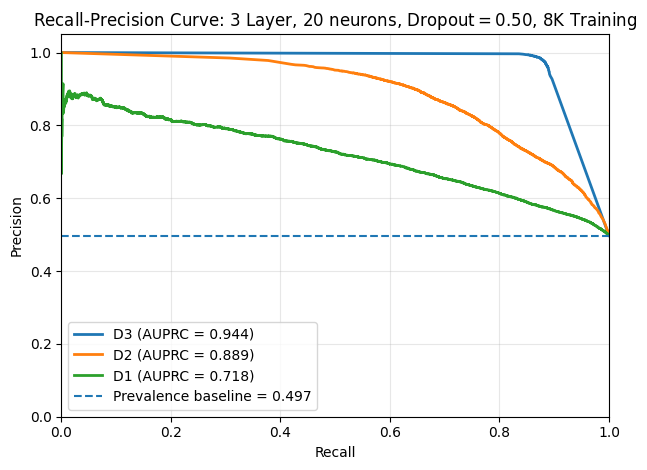


Freq NN
-----------
AUPRC       : 0.9437 0.8890 0.7176
Brier score : 0.1042 0.1617 0.2131
ECE         : 0.2019 0.1099 0.0305

First 5 coverage-risk points (Bayesian, variance-based, D3):
D3 coverage=0.061, D3 risk=0.006, D2 coverage=0.061, D2 risk=0.016, D1 coverage=0.061, D1 risk=0.130
D3 coverage=0.265, D3 risk=0.003, D2 coverage=0.265, D2 risk=0.038, D1 coverage=0.265, D1 risk=0.188
D3 coverage=0.469, D3 risk=0.014, D2 coverage=0.469, D2 risk=0.070, D1 coverage=0.469, D1 risk=0.238
D3 coverage=0.673, D3 risk=0.038, D2 coverage=0.673, D2 risk=0.113, D1 coverage=0.673, D1 risk=0.276
D3 coverage=0.878, D3 risk=0.054, D2 coverage=0.878, D2 risk=0.171, D1 coverage=0.878, D1 risk=0.309


In [ ]:
plt.figure()
B3Echo = evaluate_frequentist_model(y_true=ytest,y_prob=results_3_Echo['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
plot_pr_curves(y_true=ytest,y_prob_freq=results_3_Echo['probs_mean'],plt=plt,freq_label='D3',plot_prev=False)

B3ECG2 = evaluate_frequentist_model(y_true=ytest,y_prob=results_3_ECG2['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
plot_pr_curves(y_true=ytest,y_prob_freq=results_3_ECG2['probs_mean'],plt=plt,freq_label='D2',plot_prev=False)

B3ECG = evaluate_frequentist_model(y_true=ytest,y_prob=results_3_ECG['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
plot_pr_curves(y_true=ytest,y_prob_freq=results_3_ECG['probs_mean'],plt=plt,freq_label='D1',plot_prev=True)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Recall-Precision Curve: 3 Layer, {f_plot_name}")
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig(f"PaperFigures/NN_PRC_3layer_{f_save_name}")


print("\nFreq NN")
print("-----------")
print(f"AUPRC       : {B3Echo.auprc:.4f} {B3ECG2.auprc:.4f} {B3ECG.auprc:.4f}")
print(f"Brier score : {B3Echo.brier_score:.4f} {B3ECG2.brier_score:.4f} {B3ECG.brier_score:.4f}")
print(f"ECE         : {B3Echo.ece:.4f} {B3ECG2.ece:.4f} {B3ECG.ece:.4f}")


print("\nFirst 5 coverage-risk points (Bayesian, variance-based, D3):")
for c3, r3, c2, r2, c1, r1 in zip(
    B3Echo.coverage_risk["coverage"][3::10],
    B3Echo.coverage_risk["risk"][3::10],
    B3ECG2.coverage_risk["coverage"][3::10],
    B3ECG2.coverage_risk["risk"][3::10],
    B3ECG.coverage_risk["coverage"][3::10],
    B3ECG.coverage_risk["risk"][3::10]
):
    print(f"D3 coverage={c3:.3f}, D3 risk={r3:.3f}, D2 coverage={c2:.3f}, D2 risk={r2:.3f}, D1 coverage={c1:.3f}, D1 risk={r1:.3f}" )


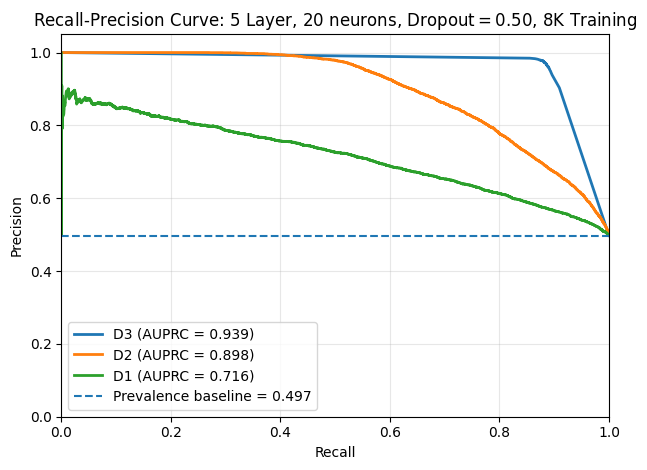


Freq NN
-----------
AUPRC       : 0.9388 0.8985 0.7160
Brier score : 0.1049 0.1621 0.2145
ECE         : 0.1989 0.1026 0.0374

First 5 coverage-risk points (Bayesian, variance-based, D3):
D3 coverage=0.061, D3 risk=0.066, D2 coverage=0.061, D2 risk=0.000, D1 coverage=0.061, D1 risk=0.135
D3 coverage=0.265, D3 risk=0.063, D2 coverage=0.265, D2 risk=0.019, D1 coverage=0.265, D1 risk=0.193
D3 coverage=0.469, D3 risk=0.059, D2 coverage=0.469, D2 risk=0.060, D1 coverage=0.469, D1 risk=0.240
D3 coverage=0.673, D3 risk=0.057, D2 coverage=0.673, D2 risk=0.117, D1 coverage=0.673, D1 risk=0.277
D3 coverage=0.878, D3 risk=0.055, D2 coverage=0.878, D2 risk=0.171, D1 coverage=0.878, D1 risk=0.313


In [ ]:
plt.figure()
B5Echo = evaluate_frequentist_model(y_true=ytest,y_prob=results_5_Echo['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
plot_pr_curves(y_true=ytest,y_prob_freq=results_5_Echo['probs_mean'],plt=plt,freq_label='D3',plot_prev=False)

B5ECG2 = evaluate_frequentist_model(y_true=ytest,y_prob=results_5_ECG2['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
plot_pr_curves(y_true=ytest,y_prob_freq=results_5_ECG2['probs_mean'],plt=plt,freq_label='D2',plot_prev=False)

B5ECG = evaluate_frequentist_model(y_true=ytest,y_prob=results_5_ECG['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
plot_pr_curves(y_true=ytest,y_prob_freq=results_5_ECG['probs_mean'],plt=plt,freq_label='D1',plot_prev=True)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Recall-Precision Curve: 5 Layer, {f_plot_name}")
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig(f"PaperFigures/NN_PRC_5layer_{f_save_name}")


print("\nFreq NN")
print("-----------")
print(f"AUPRC       : {B5Echo.auprc:.4f} {B5ECG2.auprc:.4f} {B5ECG.auprc:.4f}")
print(f"Brier score : {B5Echo.brier_score:.4f} {B5ECG2.brier_score:.4f} {B5ECG.brier_score:.4f}")
print(f"ECE         : {B5Echo.ece:.4f} {B5ECG2.ece:.4f} {B5ECG.ece:.4f}")


print("\nFirst 5 coverage-risk points (Bayesian, variance-based, D3):")
for c3, r3, c2, r2, c1, r1 in zip(
    B5Echo.coverage_risk["coverage"][3::10],
    B5Echo.coverage_risk["risk"][3::10],
    B5ECG2.coverage_risk["coverage"][3::10],
    B5ECG2.coverage_risk["risk"][3::10],
    B5ECG.coverage_risk["coverage"][3::10],
    B5ECG.coverage_risk["risk"][3::10]
):
    print(f"D3 coverage={c3:.3f}, D3 risk={r3:.3f}, D2 coverage={c2:.3f}, D2 risk={r2:.3f}, D1 coverage={c1:.3f}, D1 risk={r1:.3f}" )


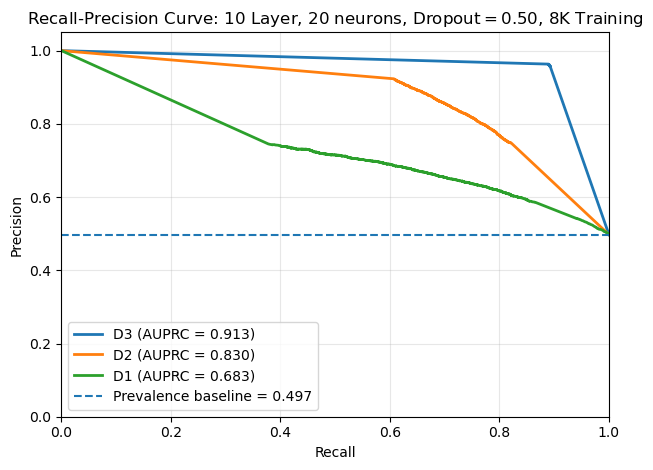


Freq NN
-----------
AUPRC       : 0.9133 0.8296 0.6829
Brier score : 0.1057 0.1632 0.2167
ECE         : 0.1979 0.0992 0.0197

First 5 coverage-risk points (Bayesian, variance-based, D3):
D3 coverage=0.061, D3 risk=0.047, D2 coverage=0.061, D2 risk=0.082, D1 coverage=0.061, D1 risk=0.246
D3 coverage=0.265, D3 risk=0.038, D2 coverage=0.265, D2 risk=0.073, D1 coverage=0.265, D1 risk=0.258
D3 coverage=0.469, D3 risk=0.038, D2 coverage=0.469, D2 risk=0.103, D1 coverage=0.469, D1 risk=0.254
D3 coverage=0.673, D3 risk=0.056, D2 coverage=0.673, D2 risk=0.136, D1 coverage=0.673, D1 risk=0.279
D3 coverage=0.878, D3 risk=0.067, D2 coverage=0.878, D2 risk=0.173, D1 coverage=0.878, D1 risk=0.316


In [ ]:
plt.figure()
B10Echo = evaluate_frequentist_model(y_true=ytest,y_prob=results_10_Echo['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
plot_pr_curves(y_true=ytest,y_prob_freq=results_10_Echo['probs_mean'],plt=plt,freq_label='D3',plot_prev=False)

B10ECG2 = evaluate_frequentist_model(y_true=ytest,y_prob=results_10_ECG2['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
plot_pr_curves(y_true=ytest,y_prob_freq=results_10_ECG2['probs_mean'],plt=plt,freq_label='D2',plot_prev=False)

B10ECG = evaluate_frequentist_model(y_true=ytest,y_prob=results_10_ECG['probs_mean'],n_bins=10,calibration_strategy='uniform',threshold=0.5,n_coverage_points=50)
plot_pr_curves(y_true=ytest,y_prob_freq=results_10_ECG['probs_mean'],plt=plt,freq_label='D1',plot_prev=True)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Recall-Precision Curve: 10 Layer, {f_plot_name}")
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig(f"PaperFigures/NN_PRC_10layer_{f_save_name}")


print("\nFreq NN")
print("-----------")
print(f"AUPRC       : {B10Echo.auprc:.4f} {B10ECG2.auprc:.4f} {B10ECG.auprc:.4f}")
print(f"Brier score : {B10Echo.brier_score:.4f} {B10ECG2.brier_score:.4f} {B10ECG.brier_score:.4f}")
print(f"ECE         : {B10Echo.ece:.4f} {B10ECG2.ece:.4f} {B10ECG.ece:.4f}")


print("\nFirst 5 coverage-risk points (Bayesian, variance-based, D3):")
for c3, r3, c2, r2, c1, r1 in zip(
    B10Echo.coverage_risk["coverage"][3::10],
    B10Echo.coverage_risk["risk"][3::10],
    B10ECG2.coverage_risk["coverage"][3::10],
    B10ECG2.coverage_risk["risk"][3::10],
    B10ECG.coverage_risk["coverage"][3::10],
    B10ECG.coverage_risk["risk"][3::10]
):
    print(f"D3 coverage={c3:.3f}, D3 risk={r3:.3f}, D2 coverage={c2:.3f}, D2 risk={r2:.3f}, D1 coverage={c1:.3f}, D1 risk={r1:.3f}" )
